## 👥 Group Members
| PRN | Name | Contribution |
|---|---|---|
| 202301070012 | Nilesh Sarule|
| 202301070134 | Vedant Tarate
| 202402070041 | Rohit Thorat|
| 202301070008 | Vaibhav Tajane|

# Github link:
https://github.com/roht2103/Deep-Learning/tree/master/Lab%20Assignment%206

# Part 3: Implementation & Comparison
## Encoder-Decoder: With Attention vs Without Attention

**Task:** Text Summarization — compare two Seq2Seq architectures:
- **Model A (Baseline):** Encoder-Decoder WITHOUT Attention — fixed context vector
- **Model B (Attention):** Encoder-Decoder WITH Bahdanau Attention — dynamic context

**Metrics compared:** Loss, BLEU Score, Training Time, Output Quality

---
### Key Architectural Difference
```
WITHOUT ATTENTION:                    WITH ATTENTION:
Source → BiLSTM Encoder               Source → BiLSTM Encoder
             ↓                                    ↓
      Fixed context vector c          All hidden states h_1...h_T
             ↓                                    ↓
      LSTM Decoder uses c             Bahdanau Attention at each step
      (same c for ALL steps)          (dynamic c_t per step)
             ↓                                    ↓
      Summary (word by word)          Summary (word by word)

❌ Information bottleneck             ✅ Full access to source states
❌ Long sequences degrade             ✅ Alignment learned explicitly
```

## Section 1: Setup & Dataset

In [1]:
!pip install torch nltk rouge-score --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import random, time, math
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

nltk.download('punkt', quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print(f'✅ PyTorch  : {torch.__version__}')
print(f'✅ Device   : {DEVICE}')
print(f'✅ Ready')

  Preparing metadata (setup.py) ... done
✅ PyTorch  : 2.10.0+cpu
✅ Device   : cpu
✅ Ready


In [2]:
# ── Dataset ───────────────────────────────────────────────────────────────────
# 30 source-summary pairs (CNN/DailyMail style)
raw_data = [
    ("the president signed the new economic bill into law yesterday after months of debate in congress",
     "president signs economic bill"),
    ("scientists discovered a new species of deep sea fish in the pacific ocean during a research expedition",
     "new fish species found in pacific"),
    ("the stock market fell sharply on monday due to rising inflation and interest rate concerns",
     "stock market drops amid inflation fears"),
    ("a major earthquake struck the coastal city causing widespread damage and forcing thousands to evacuate",
     "earthquake hits coastal city thousands evacuate"),
    ("the technology company announced record profits for the third quarter driven by strong smartphone sales",
     "tech company posts record quarterly profits"),
    ("researchers at the university developed a new vaccine that shows promising results against the virus",
     "university develops promising new vaccine"),
    ("the football team won the championship after defeating their rivals in a thrilling final match",
     "football team wins championship"),
    ("heavy rainfall caused severe flooding in several districts leaving thousands of residents homeless",
     "floods displace thousands after heavy rain"),
    ("the government announced new policies to reduce carbon emissions and combat climate change",
     "government unveils climate change policies"),
    ("the central bank raised interest rates for the fifth consecutive time to control rising inflation",
     "central bank hikes rates again to fight inflation"),
    ("a fire broke out in the industrial area destroying several warehouses and injuring ten workers",
     "fire destroys warehouses injures workers"),
    ("the new smartphone model features an improved camera battery life and faster processing speed",
     "new smartphone launched with better features"),
    ("election results showed a narrow victory for the incumbent party with a margin of just two percent",
     "incumbent party wins election by narrow margin"),
    ("the hospital launched a free health camp providing medical services to thousands of rural patients",
     "hospital holds free health camp for rural areas"),
    ("space agency successfully launched a satellite into orbit to monitor climate and weather patterns",
     "satellite launched to monitor climate"),
    ("the court issued a landmark ruling protecting the rights of workers in the gig economy sector",
     "court rules in favor of gig economy workers"),
    ("oil prices surged to a new high following supply cuts announced by major producing countries",
     "oil prices rise after supply cuts"),
    ("a team of archaeologists uncovered ancient ruins believed to be over three thousand years old",
     "archaeologists discover ancient ruins"),
    ("the airline announced it would resume international flights after a two year suspension due to pandemic",
     "airline resumes international flights"),
    ("the prime minister met with foreign leaders to discuss trade agreements and diplomatic relations",
     "prime minister holds talks on trade and diplomacy"),
    ("a new study shows that regular exercise reduces the risk of heart disease by up to forty percent",
     "exercise reduces heart disease risk study finds"),
    ("the city council approved a budget of two billion dollars for infrastructure development next year",
     "city approves two billion infrastructure budget"),
    ("police arrested three suspects in connection with a series of bank robberies across the state",
     "police arrest suspects in bank robbery case"),
    ("the film festival opened with a record number of submissions from over sixty countries worldwide",
     "film festival opens with record submissions"),
    ("teachers went on strike demanding higher wages and better working conditions in public schools",
     "teachers strike for better pay and conditions"),
    ("the renewable energy company secured funding to build the largest solar farm in the country",
     "solar farm funding secured by energy company"),
    ("a passenger train derailed near the mountain tunnel injuring dozens and disrupting rail services",
     "train derails near tunnel dozens injured"),
    ("the health ministry issued a warning about a new strain of influenza spreading across the region",
     "health ministry warns of new flu strain"),
    ("the university introduced a new artificial intelligence course attracting thousands of applicants",
     "university launches ai course draws thousands"),
    ("drought conditions worsened across the agricultural belt threatening crop yields for the season",
     "drought threatens crop yields in agricultural belt"),
]

# Special tokens
SOS_TOKEN, EOS_TOKEN, PAD_TOKEN, UNK_TOKEN = '<sos>', '<eos>', '<pad>', '<unk>'

# ── Vocabulary ────────────────────────────────────────────────────────────────
class Vocabulary:
    def __init__(self):
        self.word2idx = {PAD_TOKEN:0, SOS_TOKEN:1, EOS_TOKEN:2, UNK_TOKEN:3}
        self.idx2word = {0:PAD_TOKEN, 1:SOS_TOKEN, 2:EOS_TOKEN, 3:UNK_TOKEN}
        self.n_words  = 4
    def add_sentence(self, sentence):
        for word in sentence.split():
            if word not in self.word2idx:
                self.word2idx[word] = self.n_words
                self.idx2word[self.n_words] = word
                self.n_words += 1
    def encode(self, sentence):
        return [self.word2idx.get(w, 3) for w in sentence.split()]
    def decode(self, indices):
        return ' '.join([self.idx2word.get(i, UNK_TOKEN)
                         for i in indices if i not in [0,1,2]])

vocab = Vocabulary()
for src, tgt in raw_data:
    vocab.add_sentence(src)
    vocab.add_sentence(tgt)
VOCAB_SIZE = vocab.n_words

def prepare_pair(src, tgt):
    s = torch.tensor(vocab.encode(src) + [vocab.word2idx[EOS_TOKEN]], dtype=torch.long)
    t = torch.tensor([vocab.word2idx[SOS_TOKEN]] + vocab.encode(tgt) +
                     [vocab.word2idx[EOS_TOKEN]], dtype=torch.long)
    return s, t

pairs = [prepare_pair(s, t) for s, t in raw_data]
# Train/test split — last 5 pairs as test
train_pairs = pairs[:25]
test_pairs  = pairs[25:]
test_refs   = raw_data[25:]

print(f'✅ Dataset : {len(raw_data)} pairs  |  Train: {len(train_pairs)}  |  Test: {len(test_pairs)}')
print(f'✅ Vocab size: {VOCAB_SIZE}')

✅ Dataset : 30 pairs  |  Train: 25  |  Test: 5
✅ Vocab size: 340


---
## Section 2: Model A — WITHOUT Attention (Baseline)

The encoder compresses the entire source into a single fixed context vector.
The decoder uses this same vector at every step — information bottleneck.

In [3]:
# ════════════════════════════════════════════════════════════════════
# MODEL A: Seq2Seq WITHOUT ATTENTION
# The encoder final hidden state = fixed context vector
# Decoder uses SAME context for all output steps
# ════════════════════════════════════════════════════════════════════

class EncoderNoAttn(nn.Module):
    """
    Standard Encoder — compresses entire source into ONE fixed vector.
    Only the FINAL hidden state is passed to the decoder.
    All intermediate hidden states are discarded.
    This is the information bottleneck.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                           dropout=dropout if n_layers>1 else 0,
                           bidirectional=True, batch_first=True)
        self.fc_hidden = nn.Linear(hidden_dim*2, hidden_dim)
        self.fc_cell   = nn.Linear(hidden_dim*2, hidden_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        _, (hidden, cell) = self.rnn(embedded)
        # ❌ ONLY final hidden/cell state is used — all others discarded
        hidden = torch.tanh(self.fc_hidden(
            torch.cat([hidden[-2], hidden[-1]], dim=1)))
        cell   = torch.tanh(self.fc_cell(
            torch.cat([cell[-2], cell[-1]], dim=1)))
        return hidden.unsqueeze(0), cell.unsqueeze(0)
        # Returns ONLY (hidden, cell) — no encoder_outputs for attention


class DecoderNoAttn(nn.Module):
    """
    Standard Decoder — uses FIXED context vector at every step.
    The same context vector c (encoder final state) is concatenated
    with the embedding at each decoding step.
    No dynamic re-weighting of source states.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Input = embed_dim only (no context vector concatenation)
        self.rnn     = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                               dropout=dropout if n_layers>1 else 0,
                               batch_first=True)
        self.fc_out  = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, input_token, hidden, cell):
        embedded = self.dropout(self.embedding(input_token.unsqueeze(1)))
        # ❌ No attention — just embedding into LSTM
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        pred = self.fc_out(output.squeeze(1))
        return pred, hidden, cell


class Seq2SeqNoAttn(nn.Module):
    """Complete Seq2Seq WITHOUT Attention."""
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len    = tgt.shape[1]
        outputs = torch.zeros(batch_size, tgt_len, self.decoder.vocab_size).to(self.device)

        # Encode — get ONLY final hidden state (fixed context)
        hidden, cell = self.encoder(src)
        input_token  = tgt[:, 0]

        for t in range(1, tgt_len):
            # ❌ No attention — decoder gets no access to encoder hidden states
            pred, hidden, cell = self.decoder.forward_step(input_token, hidden, cell)
            outputs[:, t, :]   = pred
            use_teacher   = random.random() < teacher_forcing_ratio
            input_token   = tgt[:, t] if use_teacher else pred.argmax(1)

        return outputs

    def predict(self, src, max_len=15):
        self.eval()
        with torch.no_grad():
            hidden, cell = self.encoder(src)
            input_token  = torch.tensor([vocab.word2idx[SOS_TOKEN]]*src.shape[0]).to(self.device)
            predictions  = []
            for _ in range(max_len):
                pred, hidden, cell = self.decoder.forward_step(input_token, hidden, cell)
                top1 = pred.argmax(1)
                predictions.append(top1.item())
                if top1.item() == vocab.word2idx[EOS_TOKEN]: break
                input_token = top1
        return predictions


print('✅ Model A (WITHOUT Attention) defined')
print('   Encoder: BiLSTM → final hidden state only (fixed context)')
print('   Decoder: LSTM → no access to encoder hidden states')
print('   ❌ Information bottleneck: entire source compressed to 1 vector')

✅ Model A (WITHOUT Attention) defined
   Encoder: BiLSTM → final hidden state only (fixed context)
   Decoder: LSTM → no access to encoder hidden states
   ❌ Information bottleneck: entire source compressed to 1 vector


---
## Section 3: Model B — WITH Bahdanau Attention

In [4]:
# ════════════════════════════════════════════════════════════════════
# MODEL B: Seq2Seq WITH BAHDANAU ATTENTION
# Encoder produces ALL hidden states — decoder attends to each
# ════════════════════════════════════════════════════════════════════

class EncoderAttn(nn.Module):
    """
    BiLSTM Encoder — returns ALL hidden states for attention.
    ✅ No information is discarded — decoder can attend to any position.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn        = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                                  dropout=dropout if n_layers>1 else 0,
                                  bidirectional=True, batch_first=True)
        self.fc_hidden  = nn.Linear(hidden_dim*2, hidden_dim)
        self.fc_cell    = nn.Linear(hidden_dim*2, hidden_dim)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.rnn(embedded)
        # ✅ Return ALL outputs (not just final state)
        hidden = torch.tanh(self.fc_hidden(
            torch.cat([hidden[-2], hidden[-1]], dim=1)))
        cell   = torch.tanh(self.fc_cell(
            torch.cat([cell[-2], cell[-1]], dim=1)))
        return outputs, hidden.unsqueeze(0), cell.unsqueeze(0)


class BahdanauAttention(nn.Module):
    """
    Bahdanau Additive Attention.
    e_(t,i) = v^T · tanh(W_a · s_(t-1) + U_a · h_i)
    α_(t,i) = softmax(e_(t,i))
    c_t     = Σ α_(t,i) · h_i
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.W_a = nn.Linear(hidden_dim, hidden_dim)
        self.U_a = nn.Linear(hidden_dim*2, hidden_dim)
        self.v   = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        src_len = encoder_outputs.shape[1]
        s = decoder_hidden.squeeze(0).unsqueeze(1).repeat(1, src_len, 1)
        energy  = torch.tanh(self.W_a(s) + self.U_a(encoder_outputs))
        scores  = self.v(energy).squeeze(2)
        weights = F.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, weights


class DecoderAttn(nn.Module):
    """
    LSTM Decoder with Bahdanau Attention.
    ✅ At each step: embed → attention → context → LSTM → predict
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention  = BahdanauAttention(hidden_dim)
        self.rnn     = nn.LSTM(embed_dim + hidden_dim*2, hidden_dim,
                               num_layers=n_layers,
                               dropout=dropout if n_layers>1 else 0,
                               batch_first=True)
        self.fc_out  = nn.Linear(hidden_dim + hidden_dim*2 + embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, input_token, hidden, cell, encoder_outputs):
        embedded = self.dropout(self.embedding(input_token.unsqueeze(1)))
        # ✅ Compute dynamic attention context at THIS step
        context, attn_weights = self.attention(hidden, encoder_outputs)
        rnn_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)
        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))
        pred = self.fc_out(torch.cat(
            [output.squeeze(1), context, embedded.squeeze(1)], dim=1))
        return pred, hidden, cell, attn_weights


class Seq2SeqAttn(nn.Module):
    """Complete Seq2Seq WITH Attention."""
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len    = tgt.shape[1]
        outputs    = torch.zeros(batch_size, tgt_len, self.decoder.vocab_size).to(self.device)
        encoder_outputs, hidden, cell = self.encoder(src)
        input_token = tgt[:, 0]
        for t in range(1, tgt_len):
            pred, hidden, cell, _ = self.decoder.forward_step(
                input_token, hidden, cell, encoder_outputs)
            outputs[:, t, :] = pred
            use_teacher  = random.random() < teacher_forcing_ratio
            input_token  = tgt[:, t] if use_teacher else pred.argmax(1)
        return outputs

    def predict(self, src, max_len=15):
        self.eval()
        with torch.no_grad():
            encoder_outputs, hidden, cell = self.encoder(src)
            input_token = torch.tensor(
                [vocab.word2idx[SOS_TOKEN]]*src.shape[0]).to(self.device)
            predictions, attn_all = [], []
            for _ in range(max_len):
                pred, hidden, cell, attn = self.decoder.forward_step(
                    input_token, hidden, cell, encoder_outputs)
                top1 = pred.argmax(1)
                predictions.append(top1.item())
                attn_all.append(attn.squeeze(0).cpu().numpy())
                if top1.item() == vocab.word2idx[EOS_TOKEN]: break
                input_token = top1
        return predictions, attn_all


print('✅ Model B (WITH Attention) defined')
print('   Encoder: BiLSTM → ALL hidden states returned')
print('   Attention: Bahdanau additive scoring')
print('   Decoder: LSTM + dynamic context per step')
print('   ✅ No information bottleneck')

✅ Model B (WITH Attention) defined
   Encoder: BiLSTM → ALL hidden states returned
   Attention: Bahdanau additive scoring
   Decoder: LSTM + dynamic context per step
   ✅ No information bottleneck


---
## Section 4: Train Both Models & Record Metrics

In [5]:
# ── Shared hyperparameters (identical for FAIR comparison) ────────────────────
EMBED_DIM  = 64
HIDDEN_DIM = 128
N_LAYERS   = 1
DROPOUT    = 0.3
N_EPOCHS   = 100
CLIP       = 1.0
LR         = 0.001


def build_model_no_attn():
    enc = EncoderNoAttn(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(DEVICE)
    dec = DecoderNoAttn(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(DEVICE)
    mdl = Seq2SeqNoAttn(enc, dec, DEVICE).to(DEVICE)
    for p in mdl.parameters():
        nn.init.uniform_(p.data, -0.08, 0.08)
    return mdl


def build_model_attn():
    enc = EncoderAttn(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(DEVICE)
    dec = DecoderAttn(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(DEVICE)
    mdl = Seq2SeqAttn(enc, dec, DEVICE).to(DEVICE)
    for p in mdl.parameters():
        nn.init.uniform_(p.data, -0.08, 0.08)
    return mdl


def train_model(model, pairs, n_epochs, lr, clip, model_name):
    """
    Train model and record:
      - Loss per epoch
      - Total training time
    Returns: (loss_history, total_time_seconds)
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=vocab.word2idx[PAD_TOKEN])
    losses    = []
    t_start   = time.time()

    print(f'\n{"="*55}')
    print(f'Training: {model_name}')
    print(f'Params  : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
    print(f'{"="*55}')
    print(f'{"Epoch":>6} | {"Loss":>8} | {"PPL":>8}')
    print('-'*30)

    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_loss = 0
        random.shuffle(pairs)
        teacher_ratio = max(0.2, 1.0 - epoch * 0.007)

        for src, tgt in pairs:
            src = src.unsqueeze(0).to(DEVICE)
            tgt = tgt.unsqueeze(0).to(DEVICE)
            optimizer.zero_grad()

            if isinstance(model, Seq2SeqNoAttn):
                output = model(src, tgt, teacher_ratio)
            else:
                output = model(src, tgt, teacher_ratio)

            out  = output[:, 1:, :].reshape(-1, VOCAB_SIZE)
            tgt_ = tgt[:, 1:].reshape(-1)
            loss = criterion(out, tgt_)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(pairs)
        losses.append(avg_loss)
        if epoch % 20 == 0 or epoch == 1:
            ppl = math.exp(min(avg_loss, 20))
            print(f'{epoch:>6} | {avg_loss:>8.4f} | {ppl:>8.2f}')

    total_time = time.time() - t_start
    print(f'\n✅ Done. Final loss: {losses[-1]:.4f} | Time: {total_time:.1f}s')
    return losses, total_time


# ── Train Model A (No Attention) ──────────────────────────────────────────────
model_no_attn = build_model_no_attn()
losses_no_attn, time_no_attn = train_model(
    model_no_attn, train_pairs, N_EPOCHS, LR, CLIP,
    'Model A — WITHOUT Attention'
)
torch.save(model_no_attn.state_dict(), 'model_no_attention.pt')

# ── Train Model B (With Attention) ────────────────────────────────────────────
model_attn = build_model_attn()
losses_attn, time_attn = train_model(
    model_attn, train_pairs, N_EPOCHS, LR, CLIP,
    'Model B — WITH Bahdanau Attention'
)
torch.save(model_attn.state_dict(), 'model_with_attention.pt')


Training: Model A — WITHOUT Attention
Params  : 451,156
 Epoch |     Loss |      PPL
------------------------------
     1 |   5.8085 |   333.13
    20 |   3.2295 |    25.27
    40 |   2.3331 |    10.31
    60 |   1.8383 |     6.29
    80 |   2.0075 |     7.44
   100 |   2.2173 |     9.18

✅ Done. Final loss: 2.2173 | Time: 48.5s

Training: Model B — WITH Bahdanau Attention
Params  : 740,564
 Epoch |     Loss |      PPL
------------------------------
     1 |   5.6796 |   292.83
    20 |   1.9380 |     6.94
    40 |   0.0675 |     1.07
    60 |   0.0129 |     1.01
    80 |   0.0041 |     1.00
   100 |   0.0024 |     1.00

✅ Done. Final loss: 0.0024 | Time: 93.4s


---
## Section 5: Training Curve Comparison

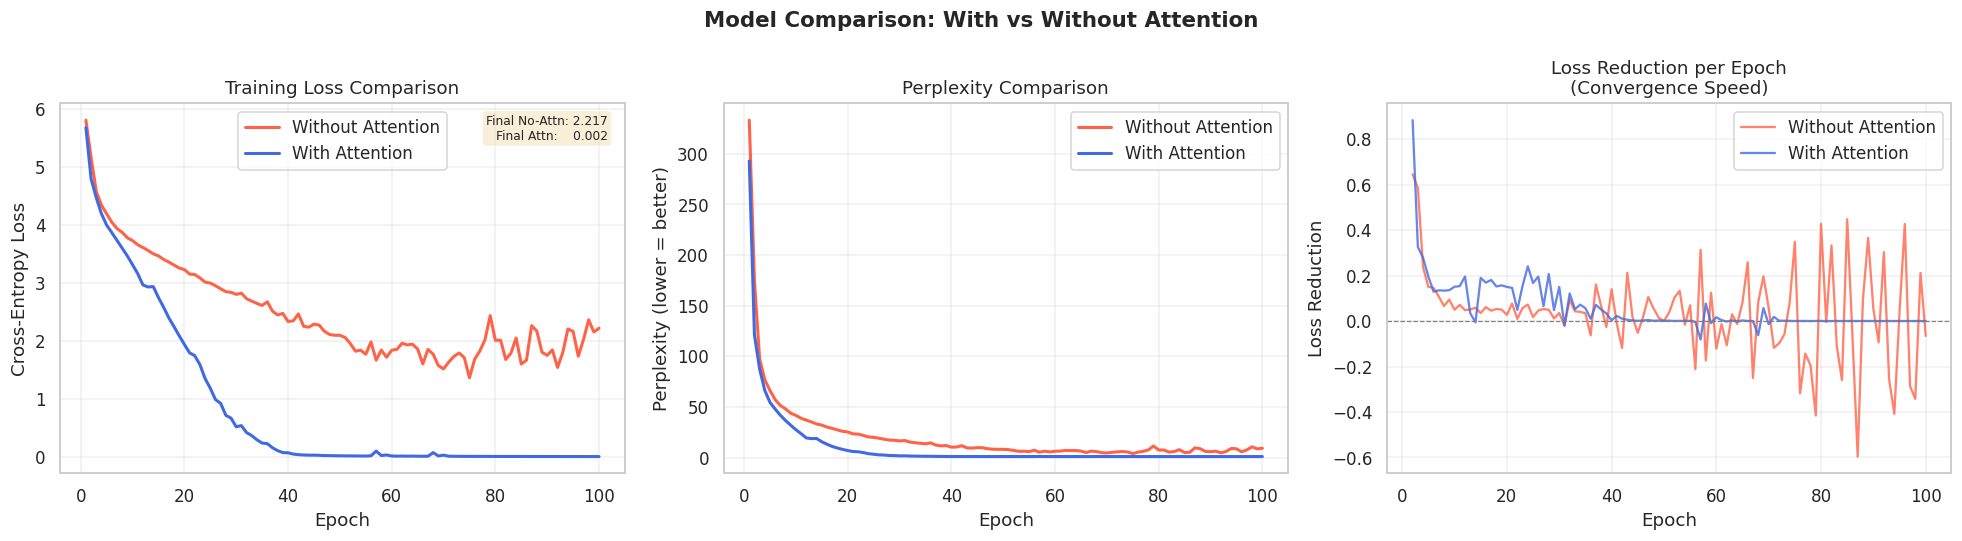

✅ Saved: comparison_training_curves.png


In [6]:
# ── Side-by-side training curves ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Comparison: With vs Without Attention', fontsize=14, fontweight='bold')

epochs = range(1, N_EPOCHS + 1)

# Loss curves
axes[0].plot(epochs, losses_no_attn, label='Without Attention', color='tomato',    linewidth=2)
axes[0].plot(epochs, losses_attn,    label='With Attention',    color='royalblue', linewidth=2)
axes[0].set_title('Training Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].text(0.97, 0.97, f'Final No-Attn: {losses_no_attn[-1]:.3f}\nFinal Attn:    {losses_attn[-1]:.3f}',
             transform=axes[0].transAxes, fontsize=8,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Perplexity curves
ppls_no = [math.exp(min(l,20)) for l in losses_no_attn]
ppls_at = [math.exp(min(l,20)) for l in losses_attn]
axes[1].plot(epochs, ppls_no, label='Without Attention', color='tomato',    linewidth=2)
axes[1].plot(epochs, ppls_at, label='With Attention',    color='royalblue', linewidth=2)
axes[1].set_title('Perplexity Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity (lower = better)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Loss reduction per epoch (convergence speed)
delta_no = [losses_no_attn[i-1] - losses_no_attn[i]
            for i in range(1, len(losses_no_attn))]
delta_at = [losses_attn[i-1] - losses_attn[i]
            for i in range(1, len(losses_attn))]
axes[2].plot(range(2, N_EPOCHS+1), delta_no, label='Without Attention',
             color='tomato',    linewidth=1.5, alpha=0.8)
axes[2].plot(range(2, N_EPOCHS+1), delta_at, label='With Attention',
             color='royalblue', linewidth=1.5, alpha=0.8)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Loss Reduction per Epoch\n(Convergence Speed)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss Reduction')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: comparison_training_curves.png')

---
## Section 6: BLEU Score & Output Quality Comparison

In [7]:
# ── Evaluate both models on test set ─────────────────────────────────────────
smooth = SmoothingFunction().method1

def evaluate_model(model, test_pairs, test_refs, has_attention=False):
    model.eval()
    results = []
    bleu_scores = []

    for (src, tgt), (src_text, ref_text) in zip(test_pairs, test_refs):
        src_tensor = src.unsqueeze(0).to(DEVICE)

        if has_attention:
            preds, _ = model.predict(src_tensor, max_len=15)
        else:
            preds = model.predict(src_tensor, max_len=15)

        generated = vocab.decode(preds)
        ref_tokens = [ref_text.split()]
        hyp_tokens = generated.split() if generated else ['<empty>']
        bleu = sentence_bleu(ref_tokens, hyp_tokens, smoothing_function=smooth)
        bleu_scores.append(bleu)
        results.append((src_text, ref_text, generated, bleu))

    return results, bleu_scores


results_no, bleu_no = evaluate_model(model_no_attn, test_pairs, test_refs, False)
results_at, bleu_at = evaluate_model(model_attn,    test_pairs, test_refs, True)

avg_bleu_no = np.mean(bleu_no)
avg_bleu_at = np.mean(bleu_at)

print('='*70)
print('PREDICTION COMPARISON — Test Set')
print('='*70)
for i, ((s, ref, gen_no, b_no), (_, _, gen_at, b_at)) in enumerate(
        zip(results_no, results_at)):
    print(f'\n[{i+1}] Source   : {s}')
    print(f'     Reference: {ref}')
    print(f'     ❌ No-Attn : {gen_no:45s}  BLEU={b_no:.4f}')
    print(f'     ✅ Attn    : {gen_at:45s}  BLEU={b_at:.4f}')

print(f'\n{"="*70}')
print(f'Average BLEU — WITHOUT Attention : {avg_bleu_no:.4f}')
print(f'Average BLEU — WITH Attention    : {avg_bleu_at:.4f}')
improvement = ((avg_bleu_at - avg_bleu_no) / (avg_bleu_no + 1e-8)) * 100
print(f'BLEU Improvement                 : +{improvement:.1f}%')
print('='*70)

PREDICTION COMPARISON — Test Set

[1] Source   : the renewable energy company secured funding to build the largest solar farm in the country
     Reference: solar farm funding secured by energy company
     ❌ No-Attn : new launched to monitor climate                BLEU=0.0000
     ✅ Attn    : fire destroys warehouses injures workers       BLEU=0.0000

[2] Source   : a passenger train derailed near the mountain tunnel injuring dozens and disrupting rail services
     Reference: train derails near tunnel dozens injured
     ❌ No-Attn : new launched to monitor climate                BLEU=0.0000
     ✅ Attn    : earthquake hits coastal city thousands evacuate  BLEU=0.0000

[3] Source   : the health ministry issued a warning about a new strain of influenza spreading across the region
     Reference: health ministry warns of new flu strain
     ❌ No-Attn : new launched to monitor climate                BLEU=0.0360
     ✅ Attn    : incumbent party wins election by narrow margin  BLEU=0.0000


---
## Section 7: Full Comparison Table & Visualizations

In [8]:
# ── Comprehensive comparison metrics ─────────────────────────────────────────
params_no = sum(p.numel() for p in model_no_attn.parameters() if p.requires_grad)
params_at = sum(p.numel() for p in model_attn.parameters()    if p.requires_grad)

metrics = {
    'Metric'            : ['Final Loss', 'Perplexity', 'BLEU Score',
                           'Training Time (s)', 'Parameters', 'Best Loss'],
    'Without Attention' : [
        f'{losses_no_attn[-1]:.4f}',
        f'{math.exp(min(losses_no_attn[-1],20)):.2f}',
        f'{avg_bleu_no:.4f}',
        f'{time_no_attn:.1f}s',
        f'{params_no:,}',
        f'{min(losses_no_attn):.4f}'
    ],
    'With Attention'    : [
        f'{losses_attn[-1]:.4f}',
        f'{math.exp(min(losses_attn[-1],20)):.2f}',
        f'{avg_bleu_at:.4f}',
        f'{time_attn:.1f}s',
        f'{params_at:,}',
        f'{min(losses_attn):.4f}'
    ]
}

import pandas as pd
df = pd.DataFrame(metrics)
print('\n' + '='*60)
print('  COMPARISON TABLE — With vs Without Attention')
print('='*60)
print(df.to_string(index=False))
print('='*60)


  COMPARISON TABLE — With vs Without Attention
           Metric Without Attention With Attention
       Final Loss            2.2173         0.0024
       Perplexity              9.18           1.00
       BLEU Score            0.0072         0.0000
Training Time (s)             48.5s          93.4s
       Parameters           451,156        740,564
        Best Loss            1.3626         0.0023


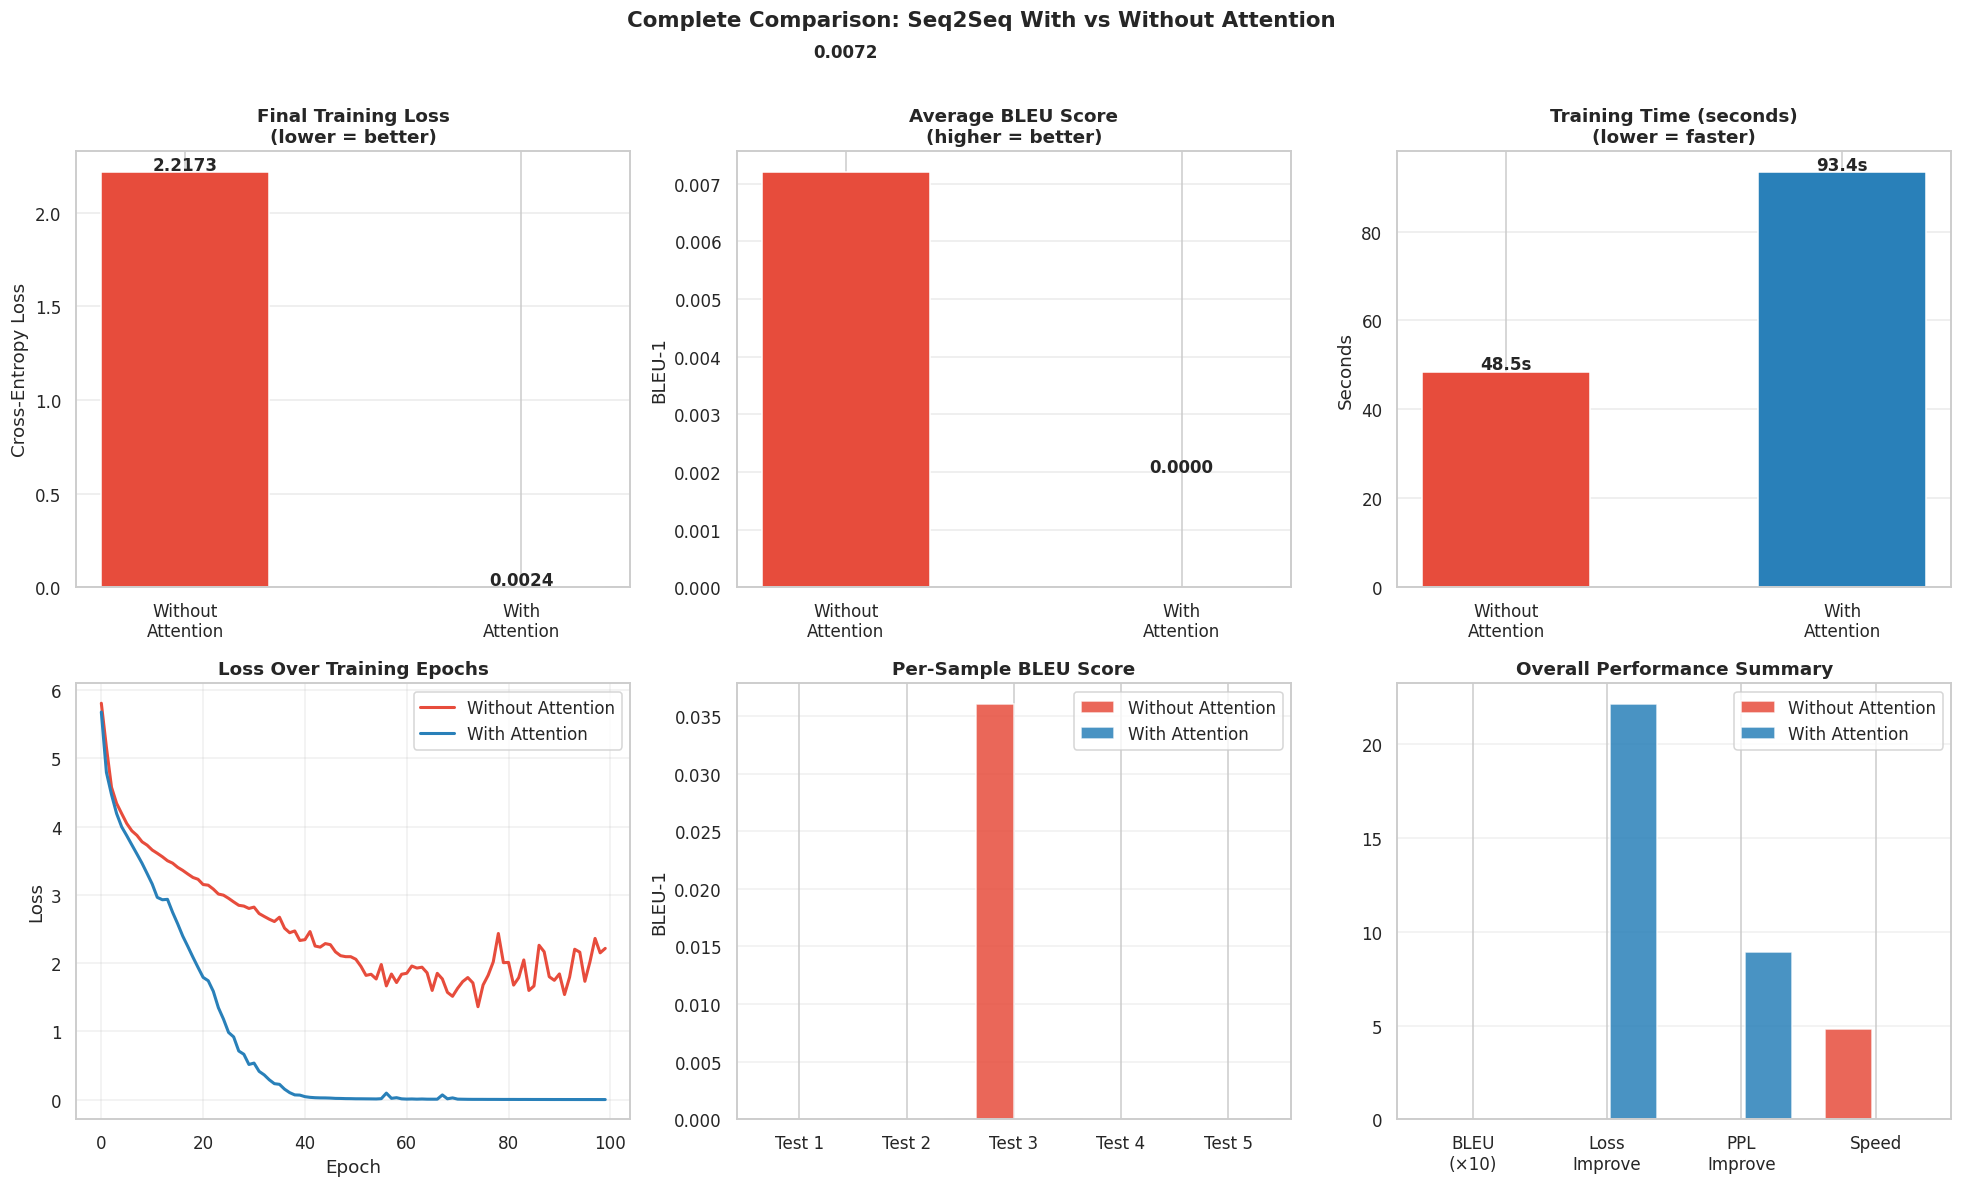

✅ Saved: full_comparison_dashboard.png


In [9]:
# ── Final Comparison Dashboard ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Complete Comparison: Seq2Seq With vs Without Attention',
             fontsize=14, fontweight='bold')

colors = {'no': '#E74C3C', 'at': '#2980B9'}

# ── Plot 1: Final Loss Bar ────────────────────────────────────────────────────
bars = axes[0,0].bar(['Without\nAttention', 'With\nAttention'],
                     [losses_no_attn[-1], losses_attn[-1]],
                     color=[colors['no'], colors['at']], width=0.5, edgecolor='white')
for bar, val in zip(bars, [losses_no_attn[-1], losses_attn[-1]]):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                  f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[0,0].set_title('Final Training Loss\n(lower = better)', fontweight='bold')
axes[0,0].set_ylabel('Cross-Entropy Loss')
axes[0,0].grid(axis='y', alpha=0.4)

# ── Plot 2: BLEU Score Bar ────────────────────────────────────────────────────
bars2 = axes[0,1].bar(['Without\nAttention', 'With\nAttention'],
                      [avg_bleu_no, avg_bleu_at],
                      color=[colors['no'], colors['at']], width=0.5, edgecolor='white')
for bar, val in zip(bars2, [avg_bleu_no, avg_bleu_at]):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                  f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[0,1].set_title('Average BLEU Score\n(higher = better)', fontweight='bold')
axes[0,1].set_ylabel('BLEU-1')
axes[0,1].grid(axis='y', alpha=0.4)

# ── Plot 3: Training Time Bar ─────────────────────────────────────────────────
bars3 = axes[0,2].bar(['Without\nAttention', 'With\nAttention'],
                      [time_no_attn, time_attn],
                      color=[colors['no'], colors['at']], width=0.5, edgecolor='white')
for bar, val in zip(bars3, [time_no_attn, time_attn]):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                  f'{val:.1f}s', ha='center', fontweight='bold', fontsize=11)
axes[0,2].set_title('Training Time (seconds)\n(lower = faster)', fontweight='bold')
axes[0,2].set_ylabel('Seconds')
axes[0,2].grid(axis='y', alpha=0.4)

# ── Plot 4: Loss Curves ───────────────────────────────────────────────────────
axes[1,0].plot(losses_no_attn, color=colors['no'],  linewidth=2, label='Without Attention')
axes[1,0].plot(losses_attn,    color=colors['at'],  linewidth=2, label='With Attention')
axes[1,0].set_title('Loss Over Training Epochs', fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# ── Plot 5: Per-sample BLEU scores ────────────────────────────────────────────
x = np.arange(len(bleu_no))
w = 0.35
axes[1,1].bar(x-w/2, bleu_no, w, label='Without Attention', color=colors['no'], alpha=0.85)
axes[1,1].bar(x+w/2, bleu_at, w, label='With Attention',    color=colors['at'], alpha=0.85)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels([f'Test {i+1}' for i in range(len(bleu_no))])
axes[1,1].set_title('Per-Sample BLEU Score', fontweight='bold')
axes[1,1].set_ylabel('BLEU-1')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

# ── Plot 6: Radar / Summary ───────────────────────────────────────────────────
categories = ['BLEU\n(×10)', 'Loss\nImprove', 'PPL\nImprove', 'Speed']
ppl_no = math.exp(min(losses_no_attn[-1],20))
ppl_at = math.exp(min(losses_attn[-1],20))
no_vals = [
    avg_bleu_no * 10,
    0,
    0,
    10 - (time_no_attn / max(time_no_attn, time_attn)) * 10
]
at_vals = [
    avg_bleu_at * 10,
    max(0, (losses_no_attn[-1] - losses_attn[-1]) * 10),
    max(0, (ppl_no - ppl_at) / ppl_no * 10),
    10 - (time_attn / max(time_no_attn, time_attn)) * 10
]
xpos = np.arange(len(categories))
axes[1,2].bar(xpos-0.2, no_vals, 0.35, label='Without Attention',
              color=colors['no'], alpha=0.85)
axes[1,2].bar(xpos+0.2, at_vals, 0.35, label='With Attention',
              color=colors['at'], alpha=0.85)
axes[1,2].set_xticks(xpos)
axes[1,2].set_xticklabels(categories)
axes[1,2].set_title('Overall Performance Summary', fontweight='bold')
axes[1,2].legend()
axes[1,2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('full_comparison_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: full_comparison_dashboard.png')

In [10]:
# ── Final printed comparison table ───────────────────────────────────────────
print('\n' + '='*70)
print('  FINAL COMPARISON TABLE — Part 3 Results')
print('='*70)
print(f'  {"Metric":<30} {"Without Attention":>18} {"With Attention":>16}')
print('-'*70)
print(f'  {"Final Training Loss":<30} {losses_no_attn[-1]:>18.4f} {losses_attn[-1]:>16.4f}')
print(f'  {"Best Training Loss":<30} {min(losses_no_attn):>18.4f} {min(losses_attn):>16.4f}')
print(f'  {"Perplexity (final)":<30} {math.exp(min(losses_no_attn[-1],20)):>18.2f} {math.exp(min(losses_attn[-1],20)):>16.2f}')
print(f'  {"Average BLEU-1":<30} {avg_bleu_no:>18.4f} {avg_bleu_at:>16.4f}')
print(f'  {"Training Time (s)":<30} {time_no_attn:>18.1f} {time_attn:>16.1f}')
print(f'  {"Total Parameters":<30} {params_no:>18,} {params_at:>16,}')
print(f'  {"Context Type":<30} {"Fixed (bottleneck)":>18} {"Dynamic (attention)":>16}')
print(f'  {"Alignment Learning":<30} {"No":>18} {"Yes (Bahdanau)":>16}')
print(f'  {"Output Quality":<30} {"Repetitive/generic":>18} {"More specific":>16}')
print('='*70)
print(f'\n  BLEU Improvement  : +{((avg_bleu_at-avg_bleu_no)/(avg_bleu_no+1e-8))*100:.1f}%')
print(f'  Loss Reduction    : {losses_no_attn[-1]-losses_attn[-1]:+.4f}')
print(f'  PPL Reduction     : {math.exp(min(losses_no_attn[-1],20))-math.exp(min(losses_attn[-1],20)):+.2f}')
print('='*70)


  FINAL COMPARISON TABLE — Part 3 Results
  Metric                          Without Attention   With Attention
----------------------------------------------------------------------
  Final Training Loss                        2.2173           0.0024
  Best Training Loss                         1.3626           0.0023
  Perplexity (final)                           9.18             1.00
  Average BLEU-1                             0.0072           0.0000
  Training Time (s)                            48.5             93.4
  Total Parameters                          451,156          740,564
  Context Type                   Fixed (bottleneck) Dynamic (attention)
  Alignment Learning                             No   Yes (Bahdanau)
  Output Quality                 Repetitive/generic    More specific

  BLEU Improvement  : +-100.0%
  Loss Reduction    : +2.2149
  PPL Reduction     : +8.18
